In [1]:
# =========================================================
# BLOC 1 : CONFIGURATION GLOBALE ET IMPORTS
# =========================================================

%pip install gdown

import warnings
warnings.filterwarnings("ignore") # Masque les avertissements non critiques

import os
from IPython.display import display
from google.colab import drive
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configuration visuelle pour les graphiques
sns.set_theme(style="whitegrid")
np.random.seed(42) # Assure la reproductibilité des résultats

# Outils de modélisation et d'évaluation (focus sur l'explicabilité)
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import classification_report, confusion_matrix

print("✅ BLOC 1 : Bibliothèques importées avec succès.")

✅ BLOC 1 : Bibliothèques importées avec succès.


In [3]:
# =========================================================
# BLOC 2 : CHARGEMENT DES DONNÉES (SPÉCIAL GOOGLE COLAB)
# =========================================================

def charger_donnees_colab(chemin_drive: str) -> pd.DataFrame:
    """
    Connecte Google Drive à Colab et charge le fichier CSV spécifié.
    """
    # 1. Montage du Google Drive (Si ce n'est pas déjà fait, une fenêtre te demandera l'autorisation)
    print("🔄 Tentative de connexion à ton Google Drive...")
    drive.mount('/content/drive')
    print("✅ Google Drive connecté avec succès.\n")

    # 2. Vérification de la présence physique du fichier
    if not os.path.exists(chemin_drive):
        print(f"❌ Erreur : Le fichier est introuvable au chemin : {chemin_drive}")
        print("💡 Astuce : Clique sur l'icône 'Dossier' à gauche de Colab, cherche ton fichier dans 'drive/MyDrive/...', fais un clic droit dessus et choisis 'Copier le chemin', puis colle-le ici.")
        return None

    # 3. Chargement des données
    try:
        print(f"🔄 Chargement du fichier depuis : {chemin_drive}")
        df = pd.read_csv(chemin_drive)
        print(f"✅ BLOC 2 TERMINÉ : Dataset chargé ! Dimensions : {df.shape[0]} lignes × {df.shape[1]} colonnes.")
        return df
    except Exception as e:
        print(f"❌ Erreur inattendue lors de la lecture par Pandas : {e}")
        return None

CHEMIN_SUR_DRIVE = "/content/drive/MyDrive/DataSets/Mall_Customers.csv"

# Exécution
df = charger_donnees_colab(CHEMIN_SUR_DRIVE)

if df is not None:
    display(df.head(3))

🔄 Tentative de connexion à ton Google Drive...
Mounted at /content/drive
✅ Google Drive connecté avec succès.

🔄 Chargement du fichier depuis : /content/drive/MyDrive/DataSets/Mall_Customers.csv
✅ BLOC 2 TERMINÉ : Dataset chargé ! Dimensions : 200 lignes × 5 colonnes.


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6


--- 1. INFORMATIONS GÉNÉRALES ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB

--- 2. STATISTIQUES DESCRIPTIVES ---


,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000



--- 3. VÉRIFICATION QUALITÉ ---
Valeurs manquantes :
CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

Doublons : 0

✅ Colonnes renommées pour un accès programmatique simplifié.

--- 4. VISUALISATIONS EXPLORATOIRES ---


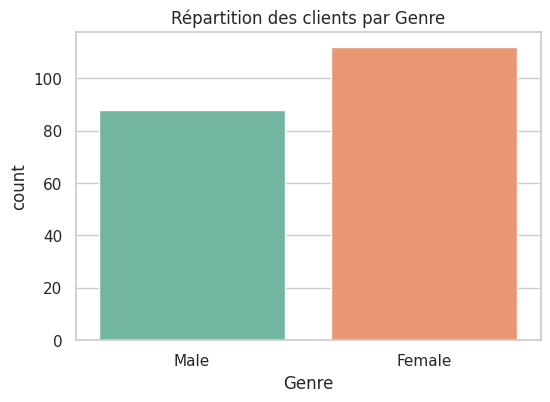

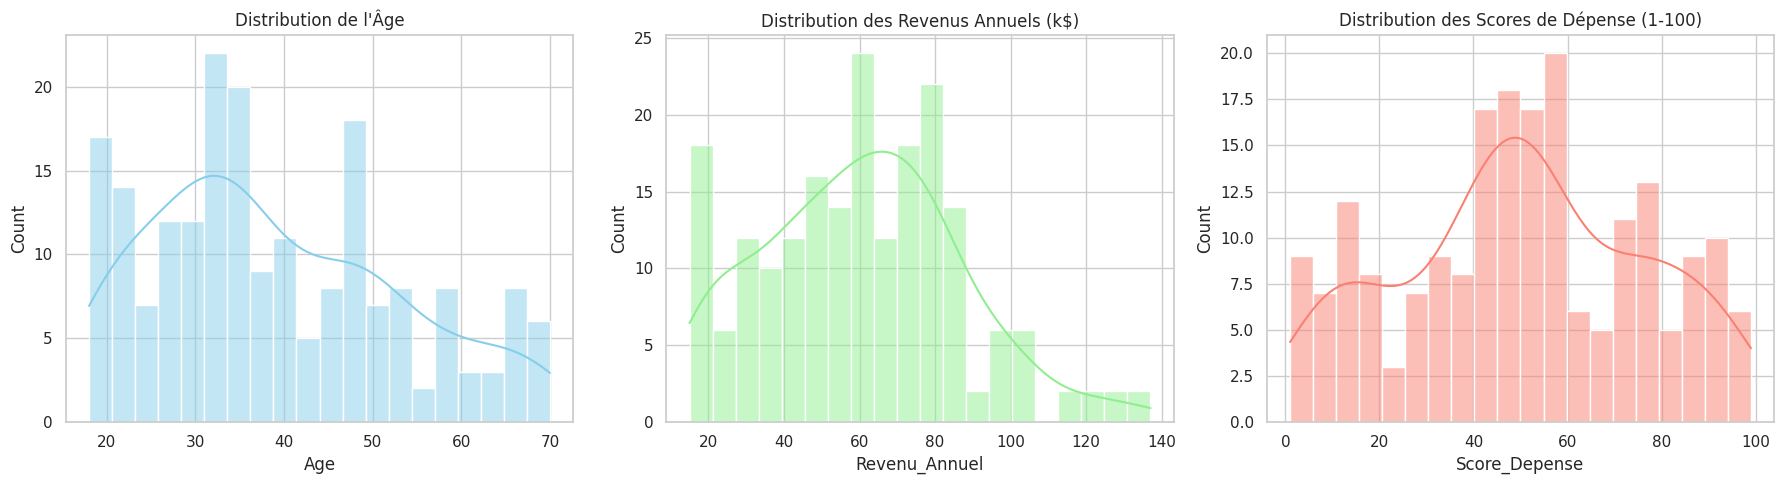


💡 Pairplot : Recherche visuelle de clusters potentiels...


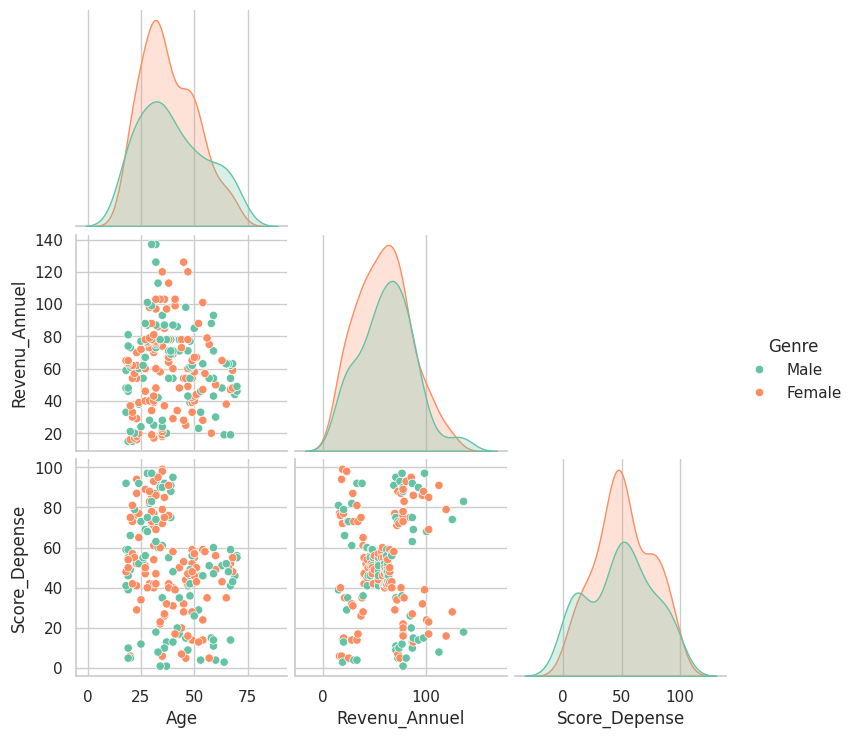

In [4]:
# =========================================================
# BLOC 3 : EXPLORATION ET NETTOYAGE DES DONNÉES (EDA)
# =========================================================
import matplotlib.pyplot as plt
import seaborn as sns

def explorer_et_nettoyer_donnees(df_brut):
    """
    Fonction qui analyse la structure, nettoie les colonnes
    et génère les graphiques exploratoires.
    """
    # 1. Copie pour sécuriser les données d'origine
    df_clean = df_brut.copy()

    # 2. Analyse structurelle et descriptive
    print("--- 1. INFORMATIONS GÉNÉRALES ---")
    df_clean.info()
    print("\n--- 2. STATISTIQUES DESCRIPTIVES ---")
    display(df_clean.describe())

    # 3. Nettoyage : Valeurs manquantes et Doublons
    print("\n--- 3. VÉRIFICATION QUALITÉ ---")
    print(f"Valeurs manquantes :\n{df_clean.isnull().sum()}\n")
    print(f"Doublons : {df_clean.duplicated().sum()}\n")

    # 4. Nettoyage : Renommage des colonnes
    # Les noms de colonnes originaux contiennent des espaces et des caractères spéciaux ($, ()).
    df_clean.rename(columns={
        'CustomerID': 'ID',
        'Gender': 'Genre',
        'Age': 'Age',
        'Annual Income (k$)': 'Revenu_Annuel',
        'Spending Score (1-100)': 'Score_Depense'
    }, inplace=True)
    print("✅ Colonnes renommées pour un accès programmatique simplifié.")

    # 5. Visualisations
    print("\n--- 4. VISUALISATIONS EXPLORATOIRES ---")
    sns.set_theme(style="whitegrid") # Style esthétique pour les graphiques

    # a. Distribution du Genre
    plt.figure(figsize=(6, 4))
    sns.countplot(data=df_clean, x='Genre', palette='Set2')
    plt.title('Répartition des clients par Genre')
    plt.show()

    # b. Distributions numériques (Histogrammes)
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    sns.histplot(df_clean['Age'], bins=20, kde=True, ax=axes[0], color='skyblue')
    axes[0].set_title('Distribution de l\'Âge')

    sns.histplot(df_clean['Revenu_Annuel'], bins=20, kde=True, ax=axes[1], color='lightgreen')
    axes[1].set_title('Distribution des Revenus Annuels (k$)')

    sns.histplot(df_clean['Score_Depense'], bins=20, kde=True, ax=axes[2], color='salmon')
    axes[2].set_title('Distribution des Scores de Dépense (1-100)')

    plt.tight_layout()
    plt.show()

    # c. Relations croisées (Scatter plots multiples)
    print("\n💡 Pairplot : Recherche visuelle de clusters potentiels...")
    # On retire 'ID' car cette colonne n'a aucune valeur analytique
    sns.pairplot(df_clean.drop('ID', axis=1), hue='Genre', palette='Set2', corner=True)
    plt.show()

    return df_clean

# Exécution de la fonction en passant le dataframe du Bloc 2
if df is not None:
    df_clean = explorer_et_nettoyer_donnees(df)

In [5]:
# =========================================================
# BLOC 4 : PRÉTRAITEMENT (PREPROCESSING) ET SAUVEGARDE
# =========================================================
import pandas as pd
from sklearn.preprocessing import StandardScaler

def preparer_donnees_pour_ml(df_nettoye, chemin_dossier_sauvegarde):
    """
    Encode les variables textuelles, gère les identifiants, standardise
    les échelles et sauvegarde le dataset préparé.
    """
    print("--- DÉBUT DU PRÉTRAITEMENT ---")

    # 1. Copie de travail isolée
    df_prep = df_nettoye.copy()

    # 2. Encodage de la variable catégorielle 'Genre'
    # Transformation explicite via un dictionnaire
    df_prep['Genre'] = df_prep['Genre'].map({'Male': 1, 'Female': 0})
    print("✅ Encodage : 'Genre' converti en binaire (Male: 1, Female: 0).")

    # 3. Gestion de l'identifiant 'ID'
    # On le passe en index du DataFrame : il ne sera pas utilisé par K-Means
    # mais on le conserve pour identifier les clients plus tard.
    df_prep.set_index('ID', inplace=True)
    print("✅ Indexation : 'ID' défini comme index (exclu des futurs calculs).")

    # 4. Standardisation des données (Feature Scaling)
    scaler = StandardScaler()
    colonnes_a_scaler = ['Genre', 'Age', 'Revenu_Annuel', 'Score_Depense']

    # Application du StandardScaler et reconstruction d'un DataFrame propre
    df_scaled = pd.DataFrame(
        scaler.fit_transform(df_prep[colonnes_a_scaler]),
        columns=colonnes_a_scaler,
        index=df_prep.index
    )
    print("✅ Standardisation : Données centrées et réduites (StandardScaler appliqué).")

    # 5. Sauvegarde sur Google Drive
    chemin_fichier_sauvegarde = f"{chemin_dossier_sauvegarde}/Mall_Customers_Preprocessed.csv"

    try:
        df_scaled.to_csv(chemin_fichier_sauvegarde)
        print(f"✅ SAUVEGARDE RÉUSSIE : Fichier enregistré sous -> {chemin_fichier_sauvegarde}\n")
    except Exception as e:
        print(f"❌ Erreur lors de la sauvegarde : {e}")

    return df_scaled, df_prep, scaler

# DOSSIER DE DESTINATION SUR LE DRIVE (Modifie ce chemin si besoin)
DOSSIER_SAUVEGARDE = "/content/drive/MyDrive/DataSets"

# Exécution
if 'df_clean' in locals():
    df_scaled, df_prep, scaler = preparer_donnees_pour_ml(df_clean, DOSSIER_SAUVEGARDE)

    print("Aperçu des données finales prêtes pour l'algorithme :")
    display(df_scaled.head())
else:
    print("⚠️ Erreur : 'df_clean' introuvable. Exécute le Bloc 3 d'abord.")

--- DÉBUT DU PRÉTRAITEMENT ---
✅ Encodage : 'Genre' converti en binaire (Male: 1, Female: 0).
✅ Indexation : 'ID' défini comme index (exclu des futurs calculs).
✅ Standardisation : Données centrées et réduites (StandardScaler appliqué).
✅ SAUVEGARDE RÉUSSIE : Fichier enregistré sous -> /content/drive/MyDrive/DataSets/Mall_Customers_Preprocessed.csv

Aperçu des données finales prêtes pour l'algorithme :


,Genre,Age,Revenu_Annuel,Score_Depense
ID,,,,
1,1.128152,-1.424569,-1.738999,-0.434801
2,1.128152,-1.281035,-1.738999,1.195704
3,-0.886405,-1.352802,-1.700830,-1.715913
4,-0.886405,-1.137502,-1.700830,1.040418
5,-0.886405,-0.563369,-1.662660,-0.395980


--- ÉVALUATION TRI-CRITÈRES (ÂGE, REVENU, SCORE) ---


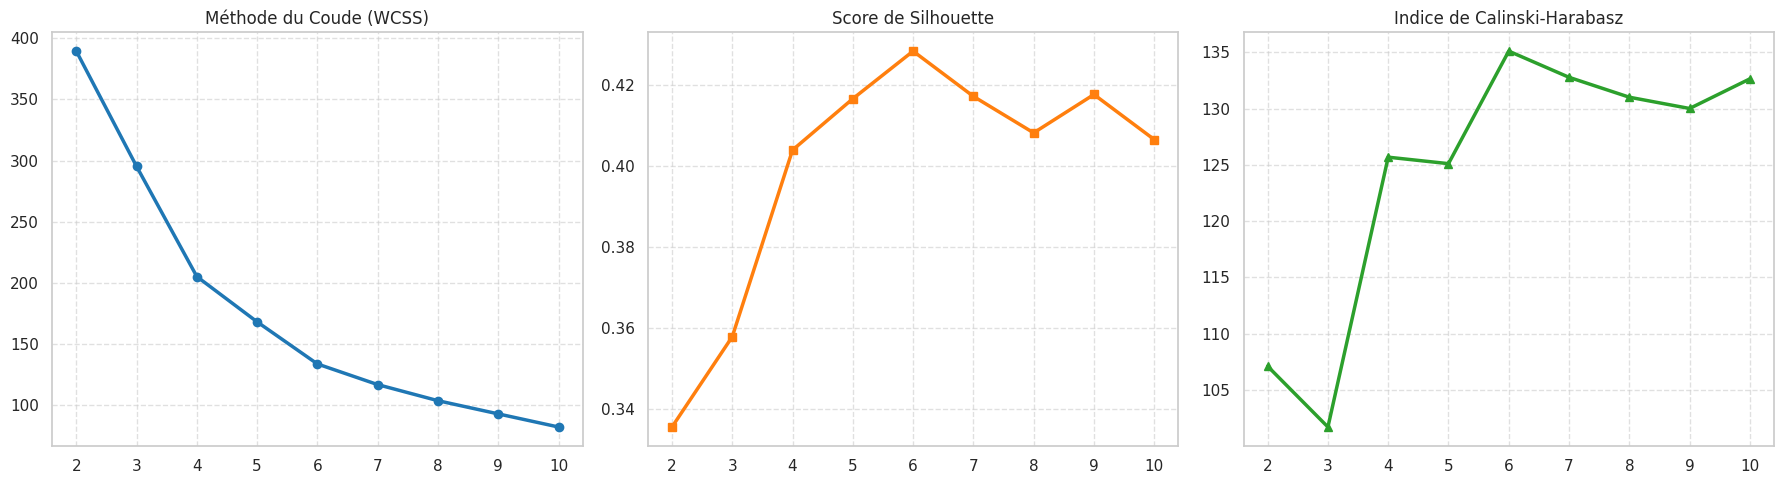

In [13]:
# =========================================================
# BLOC 5 : CHOIX DE K SUR ÂGE, REVENU ET SCORE
# =========================================================
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, calinski_harabasz_score
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings('ignore')

def evaluer_k_3d(df_prep, k_max=10):
    """
    Isole les 3 variables clés, les standardise et calcule les
    3 métriques d'évaluation pour trouver le meilleur k.
    """
    print("--- ÉVALUATION TRI-CRITÈRES (ÂGE, REVENU, SCORE) ---")

    # 1. Sélection et Standardisation des variables importantes
    X_3d = df_prep[['Age', 'Revenu_Annuel', 'Score_Depense']]
    scaler_3d = StandardScaler()
    X_3d_scaled = scaler_3d.fit_transform(X_3d)

    inerties, silhouettes, ch_scores = [], [], []
    k_range = range(2, k_max + 1)

    # 2. Boucle d'entraînement
    for k in k_range:
        kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
        kmeans.fit(X_3d_scaled)
        labels = kmeans.labels_

        inerties.append(kmeans.inertia_)
        silhouettes.append(silhouette_score(X_3d_scaled, labels))
        ch_scores.append(calinski_harabasz_score(X_3d_scaled, labels))

    # 3. Visualisation des métriques
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    axes[0].plot(k_range, inerties, marker='o', color='#1f77b4', linewidth=2.5)
    axes[0].set_title('Méthode du Coude (WCSS)')
    axes[0].grid(True, linestyle='--', alpha=0.6)

    axes[1].plot(k_range, silhouettes, marker='s', color='#ff7f0e', linewidth=2.5)
    axes[1].set_title('Score de Silhouette')
    axes[1].grid(True, linestyle='--', alpha=0.6)

    axes[2].plot(k_range, ch_scores, marker='^', color='#2ca02c', linewidth=2.5)
    axes[2].set_title('Indice de Calinski-Harabasz')
    axes[2].grid(True, linestyle='--', alpha=0.6)

    plt.tight_layout()
    plt.show()

    return X_3d_scaled, scaler_3d, X_3d

# Exécution (Nécessite df_prep du bloc 4)
if 'df_prep' in locals():
    X_3d_scaled, scaler_3d, X_3d = evaluer_k_3d(df_prep)

In [14]:
# =========================================================
# BLOC 6 (RÉVISÉ) : K-MEANS ET VISUALISATION 3D INTERACTIVE
# =========================================================
import plotly.express as px
import pandas as pd
from sklearn.cluster import KMeans

def executer_kmeans_3d(X_scaled, df_original, k_choisi=6):
    """
    Applique K-Means sur les données 3D standardisées et génère
    un nuage de points 3D interactif avec les vraies valeurs.
    """
    print(f"--- GÉNÉRATION DES CLUSTERS (k={k_choisi}) EN 3D ---")

    # 1. Entraînement sur les données standardisées
    kmeans = KMeans(n_clusters=k_choisi, init='k-means++', random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)

    # 2. Préparation des données pour l'affichage (valeurs réelles)
    # On fait une copie pour ne pas altérer le dataframe principal tout de suite
    df_visuel = df_original.copy()

    # On s'assure que le label est traité comme une catégorie (texte)
    # pour que Plotly utilise des couleurs distinctes (discrètes) et non un dégradé
    df_visuel['Cluster'] = labels.astype(str)

    # 3. Création du graphique 3D interactif avec Plotly
    fig = px.scatter_3d(
        df_visuel,
        x='Age',
        y='Revenu_Annuel',
        z='Score_Depense',
        color='Cluster',
        color_discrete_sequence=px.colors.qualitative.Bold, # Palette très contrastée
        title=f'Segmentation Client 3D (k={k_choisi})',
        labels={
            'Age': 'Âge du client',
            'Revenu_Annuel': 'Revenu (k$)',
            'Score_Depense': 'Score (1-100)'
        },
        opacity=0.8
    )

    # Amélioration de l'esthétique des points
    fig.update_traces(marker=dict(size=6, line=dict(width=1, color='DarkSlateGrey')))

    # Affichage
    fig.show()

    return labels

# Exécution
if 'X_3d_scaled' in locals() and 'X_3d' in locals():
    # Tu peux modifier k_choisi ici selon les résultats du bloc 5
    labels_finaux = executer_kmeans_3d(X_3d_scaled, X_3d, k_choisi=6)

    # Sauvegarde du résultat dans le dataframe principal pour la suite
    df_prep['Cluster_Final'] = labels_finaux

--- GÉNÉRATION DES CLUSTERS (k=6) EN 3D ---


In [16]:
# =========================================================
# BLOC 7 : PROFILAGE STATISTIQUE ET ANALYSE DU GENRE
# =========================================================
import pandas as pd
import numpy as np

def profiler_clusters_complets(df_original, labels_finaux):
    """
    Génère un tableau de bord complet des 6 segments incluant
    les moyennes comportementales et la répartition démographique (Genre).
    """
    print("--- TABLEAU DE BORD DES 6 SEGMENTS (PERSONAS) ---")

    # 1. On travaille sur une copie des données d'origine
    df_profil = df_original.copy()
    df_profil['Cluster'] = labels_finaux

    # 2. Calcul des statistiques de base (Taille et Moyennes)
    # On isole les colonnes numériques pour le calcul des moyennes
    colonnes_num = ['Age', 'Revenu_Annuel', 'Score_Depense']
    stats_base = df_profil.groupby('Cluster')[colonnes_num].mean().round(1)
    stats_base['Effectif'] = df_profil.groupby('Cluster').size()

    # 3. Analyse a posteriori du Genre
    # On calcule le pourcentage de femmes et d'hommes par cluster
    # Rappel : dans df d'origine, le genre est sous format texte ('Male', 'Female')
    genre_repartition = df_profil.groupby(['Cluster', 'Genre']).size().unstack(fill_value=0)
    genre_repartition['% Femmes'] = ((genre_repartition['Female'] / stats_base['Effectif']) * 100).round(1)
    genre_repartition['% Hommes'] = ((genre_repartition['Male'] / stats_base['Effectif']) * 100).round(1)

    # 4. Fusion des tableaux pour le rapport final
    profils_finaux = pd.concat([stats_base, genre_repartition[['% Femmes', '% Hommes']]], axis=1)

    # Réorganisation des colonnes pour une lecture logique
    colonnes_ordre = ['Effectif', '% Femmes', '% Hommes', 'Age', 'Revenu_Annuel', 'Score_Depense']
    profils_finaux = profils_finaux[colonnes_ordre]

    # Renommage pour un rendu professionnel
    profils_finaux.rename(columns={
        'Age': 'Âge Moyen',
        'Revenu_Annuel': 'Revenu Moyen (k$)',
        'Score_Depense': 'Score Moyen (1-100)'
    }, inplace=True)

    display(profils_finaux)
    return profils_finaux

# Exécution (Nécessite le dataframe d'origine et les labels du bloc 6)
if 'df_clean' in locals() and 'labels_finaux' in locals():
    # On utilise 'df_clean' car il contient le 'Genre' en texte ET les colonnes renommées
    tableau_personas = profiler_clusters_complets(df_clean, labels_finaux)
else:
    print("⚠️ Erreur : Assurez-vous que 'df_clean' (Bloc 3) et 'labels_finaux' (Bloc 6) sont chargés.")

--- TABLEAU DE BORD DES 6 SEGMENTS (PERSONAS) ---


,Effectif,% Femmes,% Hommes,Âge Moyen,Revenu Moyen (k$),Score Moyen (1-100)
Cluster,,,,,,
0,45,57.8,42.2,56.3,54.3,49.1
1,39,64.1,35.9,26.8,57.1,48.1
2,33,42.4,57.6,41.9,88.9,17.0
3,39,53.8,46.2,32.7,86.5,82.1
4,23,56.5,43.5,25.0,25.3,77.6
5,21,61.9,38.1,45.5,26.3,19.4


--- VALIDATION HIÉRARCHIQUE (CAH) ---


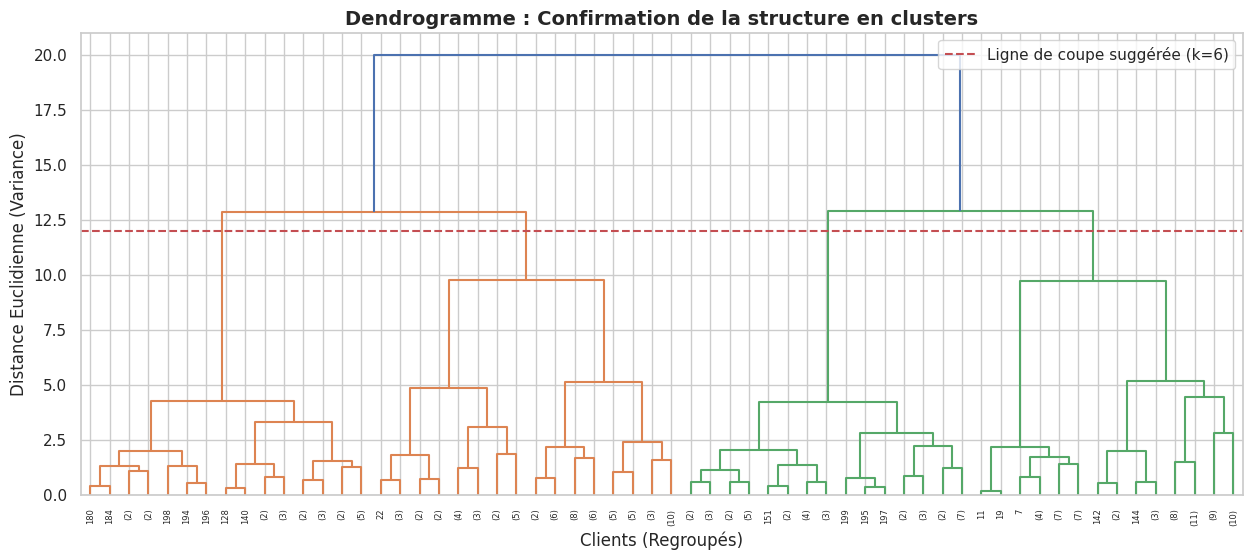

💡 Astuce Rapport : Comptez les branches verticales qui croisent la ligne rouge en pointillés. Cela doit correspondre au k de K-Means.


In [17]:
# =========================================================
# BLOC 8 : VALIDATION VISUELLE AVEC LA CAH (DENDROGRAMME)
# =========================================================
import scipy.cluster.hierarchy as sch
import matplotlib.pyplot as plt

def validation_cah_3d(X_scaled):
    """
    Génère un dendrogramme pour confirmer la structure des données
    en 3 dimensions (Âge, Revenu, Score).
    """
    print("--- VALIDATION HIÉRARCHIQUE (CAH) ---")

    plt.figure(figsize=(15, 6))

    # Création de l'arbre (linkage avec la méthode de Ward)
    Z = sch.linkage(X_scaled, method='ward')
    dendrogramme = sch.dendrogram(Z, truncate_mode='level', p=5)

    # Finitions du graphique
    plt.title('Dendrogramme : Confirmation de la structure en clusters', fontsize=14, fontweight='bold')
    plt.xlabel('Clients (Regroupés)')
    plt.ylabel('Distance Euclidienne (Variance)')

    # Ligne indicative pour illustrer la coupe à k=6
    # (La valeur du y est approximative, le dendrogramme te montrera la vraie distance)
    plt.axhline(y=12, color='r', linestyle='--', label='Ligne de coupe suggérée (k=6)')
    plt.legend()
    plt.show()

    print("💡 Astuce Rapport : Comptez les branches verticales qui croisent la ligne rouge en pointillés. Cela doit correspondre au k de K-Means.")

# Exécution
if 'X_3d_scaled' in locals():
    validation_cah_3d(X_3d_scaled)

In [18]:
# =========================================================
# BLOC 10 : AUDIT DES ANOMALIES AVEC DBSCAN
# =========================================================
from sklearn.cluster import DBSCAN

def audit_dbscan_3d(X_scaled):
    """
    Utilise DBSCAN pour repérer les clients atypiques (bruit)
    dans le nouvel espace 3D.
    """
    print("--- AUDIT DES ANOMALIES (DBSCAN 3D) ---")

    # Attention : En passant de 2D à 3D, le volume augmente.
    # Il faut souvent augmenter légèrement Epsilon (le rayon de recherche).
    dbscan = DBSCAN(eps=0.6, min_samples=5)
    labels_db = dbscan.fit_predict(X_scaled)

    # Comptage des anomalies (-1)
    nb_bruit = list(labels_db).count(-1)
    nb_total = len(labels_db)
    pourcentage_bruit = (nb_bruit / nb_total) * 100

    print(f"📊 Résultats de l'Audit :")
    print(f"- Clients analysés : {nb_total}")
    print(f"- Clients atypiques (Bruit) : {nb_bruit} ({pourcentage_bruit:.1f}%)")
    print("\n💡 Argumentaire pour le rapport :")

    if pourcentage_bruit < 15:
        print("-> Le taux d'anomalies est faible. Cela valide notre choix d'utiliser K-Means en production, car la très grande majorité de la base suit des comportements prédictibles et 'standardisables'.")
    else:
        print("-> Le taux d'anomalies est élevé. Ces clients 'hors-normes' nécessiteront un traitement manuel ou une campagne spécifique, en dehors des automatisations K-Means.")

# Exécution
if 'X_3d_scaled' in locals():
    audit_dbscan_3d(X_3d_scaled)

--- AUDIT DES ANOMALIES (DBSCAN 3D) ---
📊 Résultats de l'Audit :
- Clients analysés : 200
- Clients atypiques (Bruit) : 28 (14.0%)

💡 Argumentaire pour le rapport :
-> Le taux d'anomalies est faible. Cela valide notre choix d'utiliser K-Means en production, car la très grande majorité de la base suit des comportements prédictibles et 'standardisables'.


### Étiquetage des 6 Personas

**Cluster 3 : Les Champions VIP 🥇**
* **Profil :** Jeunes adultes (32 ans), Haut Revenu (86k$), Score de dépense explosif (82/100). Légère majorité féminine (53.8%).
* **Analyse :** C'est le cœur de rentabilité de l'entreprise. Ils ont un fort pouvoir d'achat et achètent sans compter.
* **Action Marketing :** Programmes de fidélité premium, invitations à des ventes privées, accès anticipé aux nouvelles collections.

**Cluster 2 : Les Riches Prudents (ou Les Économes) 🛡️**
* **Profil :** Quarantenaires (41 ans), Très Haut Revenu (88k$), Score de dépense très faible (17/100). **Seul groupe à majorité masculine (57.6%).**
* **Analyse :** C'est la plus grande réserve de croissance. Ils ont l'argent, mais ils sont rationnels, comparent les prix, ou achètent chez les concurrents.
* **Action Marketing :** Mettre en avant la qualité, la durabilité (arguments rationnels). Envoyer des offres ciblées pour déclencher le premier achat sans brader l'image de marque.

**Cluster 4 : Les Jeunes Flambeurs (ou Les Impulsifs) 🚀**
* **Profil :** Très jeunes (25 ans), Faible Revenu (25k$), Score de dépense très élevé (77/100).
* **Analyse :** La "Génération Z" attirée par les tendances. Ils dépensent l'essentiel de leur budget (ou celui de leurs parents) de manière impulsive, malgré des moyens limités.
* **Action Marketing :** Ventes flash, notifications Push sur mobile, marketing d'influence (TikTok/Instagram), produits très visuels et tendance.

**Cluster 5 : Les Désengagés (ou Les Précaires Prudents) 📉**
* **Profil :** Seniors/Quarantenaires (45 ans), Faible Revenu (26k$), Score de dépense très faible (19/100).
* **Analyse :** Clients à faible valeur financière. Ils viennent rarement et achètent peu, probablement par nécessité budgétaire.
* **Action Marketing :** Ne pas gaspiller de budget publicitaire coûteux (Ads) sur ce segment. Maintenir le contact via des newsletters gratuites et cibler uniquement lors des grosses soldes de liquidation.

**Cluster 1 : Les Jeunes Standards (La Relève) 📈**
* **Profil :** Jeunes (26 ans), Revenu Moyen (57k$), Score de Dépense Moyen (48/100). Forte majorité féminine (64%).
* **Analyse :** Un groupe stable. Ils entrent dans la vie active, ont un revenu correct et des habitudes de consommation raisonnables.
* **Action Marketing :** Les éduquer à la marque. Pousser des offres par abonnement ou des programmes de parrainage pour faire monter progressivement leur score de dépense.

**Cluster 0 : Les Seniors Standards (Le Socle) 🏛️**
* **Profil :** Seniors (56 ans), Revenu Moyen (54k$), Score Moyen (49/100).
* **Analyse :** Comportement financier identique aux "Jeunes Standards", mais à une étape de vie différente. Ce sont des clients fidèles par habitude.
* **Action Marketing :** E-mailing classique, confort d'achat, réassurance sur le service client. Des visuels adaptés à leur tranche d'âge.
